In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 5.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 106.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 104.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [datasets]4/5 [datasets]ess]


In [2]:
import requests
r = requests.get("http://localhost:8000/v1/models")
print(r.json())

{'object': 'list', 'data': [{'id': 'Qwen/Qwen2.5-7B-Instruct', 'object': 'model', 'created': 1787943234, 'owned_by': 'vllm', 'root': 'Qwen/Qwen2.5-7B-Instruct', 'parent': None, 'max_model_len': 32768, 'permission': [{'id': 'modelperm-af75a79abdd3cb54', 'object': 'model_permission', 'created': 1787943234, 'allow_create_engine': False, 'allow_sampling': True, 'allow_logprobs': True, 'allow_search_indices': False, 'allow_view': True, 'allow_fine_tuning': False, 'organization': '*', 'group': None, 'is_blocking': False}]}]}


In [3]:
import random
from datasets import load_dataset

random.seed(42)
CHOICES = ["A", "B", "C", "D"]

def format_question(example, include_answer=True):
    q = example["question"]
    choices = example["choices"]
    prompt = q + "\n"
    for label, choice in zip(CHOICES, choices):
        prompt += f"{label}. {choice}\n"
    prompt += "Answer:"
    if include_answer:
        prompt += f" {CHOICES[example['answer']]}\n\n"
    return prompt

dataset = load_dataset("cais/mmlu", "all")
test_set = dataset["test"]
dev_set = dataset["dev"]

few_shot_examples = dev_set.select(range(5))
fixed_prefix = ""
for ex in few_shot_examples:
    fixed_prefix += format_question(ex, include_answer=True)

random.seed(0)
indices = random.sample(range(len(test_set)), 500)
items = test_set.select(indices)

prompts = []
for ex in items:
    full_prompt = fixed_prefix + format_question(ex, include_answer=False)
    prompts.append({
        "prompt": full_prompt,
        "answer": CHOICES[ex["answer"]],
        "subject": ex["subject"],
    })

print(f"Built {len(prompts)} prompts.")

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

all/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.50MB            

all/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

all/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  408kB            

...

Generating test split:   0%|          | 0/14042 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1531 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating auxiliary_train split:   0%|          | 0/99842 [00:00<?, ? examples/s]

Built 500 prompts.


In [9]:
import asyncio
from openai import AsyncOpenAI
import time
import re

def extract_answer(text):
    text = text.strip()
    match = re.search(r"\b([ABCD])\b", text)
    if match:
        return match.group(1)
    if text and text[0] in "ABCD":
        return text[0]
    return None

async def run_one(client, item, model):
    start = time.perf_counter()
    response = await client.completions.create(
        model=model,
        prompt=item["prompt"],
        max_tokens=5,
        temperature=0,
    )
    elapsed = time.perf_counter() - start
    raw_output = response.choices[0].text
    predicted = extract_answer(raw_output)
    usage = response.usage
    return {
        "subject": item["subject"],
        "predicted": predicted,
        "answer": item["answer"],
        "correct": predicted == item["answer"],
        "latency_sec": elapsed,
        "prompt_tokens": usage.prompt_tokens if usage else None,
        "completion_tokens": usage.completion_tokens if usage else None,
    }

import httpx
from openai import AsyncOpenAI

async def run_eval_concurrent(prompts_ordered, model, concurrency=64, port=8000):
    client = AsyncOpenAI(
        base_url=f"http://localhost:{port}/v1",
        api_key="not-needed",
        http_client=httpx.AsyncClient(
            limits=httpx.Limits(max_connections=concurrency + 50, max_keepalive_connections=concurrency)
        ),
    )
    semaphore = asyncio.Semaphore(concurrency)

    async def bounded_run(item):
        async with semaphore:
            return await run_one(client, item, model)

    overall_start = time.perf_counter()
    tasks = [bounded_run(item) for item in prompts_ordered]
    results = await asyncio.gather(*tasks)
    overall_elapsed = time.perf_counter() - overall_start

    correct = sum(r["correct"] for r in results)
    total = len(results)
    summary = {
        "accuracy": correct / total,
        "total_wall_time_sec": overall_elapsed,
        "avg_latency_sec": sum(r["latency_sec"] for r in results) / total,
        "throughput_req_per_sec": total / overall_elapsed,
        "n": total,
        "client_concurrency": concurrency,
    }
    return summary, results

In [5]:
summary, results = await run_eval_concurrent(prompts, "Qwen/Qwen2.5-7B-Instruct", concurrency=64)
print(summary)

{'accuracy': 0.74, 'total_wall_time_sec': 3.3753655939362943, 'avg_latency_sec': 0.3706332548619248, 'throughput_req_per_sec': 148.1321018671961, 'n': 500, 'client_concurrency': 64}


In [6]:
import subprocess
import time
import random
import json
import os
import requests
import asyncio

MODEL = "Qwen/Qwen2.5-7B-Instruct"
SERVER_PORT = 8000
MAX_NUM_SEQS_VALUES = [32, 128, 256]
CACHING_VALUES = [True, False]
RESULTS_DIR = "sweep_results_concurrent"
os.makedirs(RESULTS_DIR, exist_ok=True)

def start_server(enable_caching, max_num_seqs):
    cmd = [
        "vllm", "serve", MODEL,
        "--max-num-seqs", str(max_num_seqs),
        "--port", str(SERVER_PORT),
    ]
    if enable_caching:
        cmd.append("--enable-prefix-caching")

    env = os.environ.copy()
    env["VLLM_USE_FLASHINFER_SAMPLER"] = "0"

    print(f"Starting server: caching={enable_caching}, max_num_seqs={max_num_seqs}")
    proc = subprocess.Popen(
        cmd, env=env,
        stdout=open(f"{RESULTS_DIR}/server_log_{enable_caching}_{max_num_seqs}.txt", "w"),
        stderr=subprocess.STDOUT,
    )
    return proc

def wait_for_server(timeout=600):
    start = time.perf_counter()
    while time.perf_counter() - start < timeout:
        try:
            r = requests.get(f"http://localhost:{SERVER_PORT}/v1/models", timeout=3)
            if r.status_code == 200:
                print("Server ready.")
                return True
        except requests.exceptions.ConnectionError:
            pass
        time.sleep(5)
    raise TimeoutError("Server did not come up in time.")

def stop_server(proc):
    print("Stopping server...")
    proc.terminate()
    try:
        proc.wait(timeout=30)
    except subprocess.TimeoutExpired:
        proc.kill()
        proc.wait()
    time.sleep(5)

sorted_prompts = sorted(prompts, key=lambda x: len(x["prompt"]))
shuffled_prompts = prompts.copy()
random.seed(123)
random.shuffle(shuffled_prompts)
orderings = [("sorted", sorted_prompts), ("shuffled", shuffled_prompts)]

all_summaries = []

for caching in CACHING_VALUES:
    for max_num_seqs in MAX_NUM_SEQS_VALUES:
        proc = start_server(caching, max_num_seqs)
        try:
            wait_for_server()
            for order_label, ordered_prompts in orderings:
                # client concurrency matches the server's batch limit
                # so the batching variable actually gets exercised
                summary, results = await run_eval_concurrent(
                    ordered_prompts, MODEL,
                    concurrency=max_num_seqs,
                    port=SERVER_PORT,
                )
                summary["caching"] = caching
                summary["max_num_seqs"] = max_num_seqs
                summary["order"] = order_label

                run_id = f"cache_{caching}_maxseqs_{max_num_seqs}_{order_label}"
                with open(f"{RESULTS_DIR}/{run_id}_detail.json", "w") as f:
                    json.dump(results, f)
                with open(f"{RESULTS_DIR}/{run_id}_summary.json", "w") as f:
                    json.dump(summary, f, indent=2)

                print(f"Done: {summary}")
                all_summaries.append(summary)
        finally:
            stop_server(proc)

with open(f"{RESULTS_DIR}/sweep_summary.json", "w") as f:
    json.dump(all_summaries, f, indent=2)

print("\nSweep complete.")
for s in all_summaries:
    print(s)

Starting server: caching=True, max_num_seqs=32
Server ready.
Done: {'accuracy': 0.74, 'total_wall_time_sec': 2.0820301200728863, 'avg_latency_sec': 0.1259711088659242, 'throughput_req_per_sec': 240.1502241391668, 'n': 500, 'client_concurrency': 32, 'caching': True, 'max_num_seqs': 32, 'order': 'sorted'}
Done: {'accuracy': 0.738, 'total_wall_time_sec': 1.9972888890188187, 'avg_latency_sec': 0.12009651357750409, 'throughput_req_per_sec': 250.33934887888364, 'n': 500, 'client_concurrency': 32, 'caching': True, 'max_num_seqs': 32, 'order': 'shuffled'}
Stopping server...
Starting server: caching=True, max_num_seqs=128
Server ready.
Done: {'accuracy': 0.74, 'total_wall_time_sec': 1.5293163530295715, 'avg_latency_sec': 0.3408808057704009, 'throughput_req_per_sec': 326.9434731470054, 'n': 500, 'client_concurrency': 128, 'caching': True, 'max_num_seqs': 128, 'order': 'sorted'}
Done: {'accuracy': 0.738, 'total_wall_time_sec': 1.3191549440380186, 'avg_latency_sec': 0.30489409565739334, 'throughpu

CancelledError: 

In [10]:
summary_sorted, results_sorted = await run_eval_concurrent(
    sorted_prompts, MODEL, concurrency=256, port=SERVER_PORT
)
summary_sorted["caching"] = True
summary_sorted["max_num_seqs"] = 256
summary_sorted["order"] = "sorted"
print(summary_sorted)

summary_shuffled, results_shuffled = await run_eval_concurrent(
    shuffled_prompts, MODEL, concurrency=256, port=SERVER_PORT
)
summary_shuffled["caching"] = True
summary_shuffled["max_num_seqs"] = 256
summary_shuffled["order"] = "shuffled"
print(summary_shuffled)

{'accuracy': 0.742, 'total_wall_time_sec': 6.26771047397051, 'avg_latency_sec': 2.579422074615024, 'throughput_req_per_sec': 79.77394649553057, 'n': 500, 'client_concurrency': 256, 'caching': True, 'max_num_seqs': 256, 'order': 'sorted'}
{'accuracy': 0.74, 'total_wall_time_sec': 6.275713243987411, 'avg_latency_sec': 2.4487437730508392, 'throughput_req_per_sec': 79.67221900698479, 'n': 500, 'client_concurrency': 256, 'caching': True, 'max_num_seqs': 256, 'order': 'shuffled'}


In [11]:
CACHING_FALSE_RESULTS = []

for max_num_seqs in [32, 128, 256]:
    proc = start_server(False, max_num_seqs)
    try:
        wait_for_server()
        for order_label, ordered_prompts in [("sorted", sorted_prompts), ("shuffled", shuffled_prompts)]:
            summary, results = await run_eval_concurrent(
                ordered_prompts, MODEL, concurrency=max_num_seqs, port=SERVER_PORT
            )
            summary["caching"] = False
            summary["max_num_seqs"] = max_num_seqs
            summary["order"] = order_label
            print(summary)
            CACHING_FALSE_RESULTS.append(summary)
    finally:
        stop_server(proc)

Starting server: caching=False, max_num_seqs=32
Server ready.
{'accuracy': 0.736, 'total_wall_time_sec': 1.9041836539981887, 'avg_latency_sec': 0.11695901971543207, 'throughput_req_per_sec': 262.5797143831987, 'n': 500, 'client_concurrency': 32, 'caching': False, 'max_num_seqs': 32, 'order': 'sorted'}
{'accuracy': 0.738, 'total_wall_time_sec': 1.6650071369949728, 'avg_latency_sec': 0.10081046625575982, 'throughput_req_per_sec': 300.29901307354555, 'n': 500, 'client_concurrency': 32, 'caching': False, 'max_num_seqs': 32, 'order': 'shuffled'}
Stopping server...
Starting server: caching=False, max_num_seqs=128
Server ready.
{'accuracy': 0.736, 'total_wall_time_sec': 5.739228319958784, 'avg_latency_sec': 1.4094359074120875, 'throughput_req_per_sec': 87.11972622890715, 'n': 500, 'client_concurrency': 128, 'caching': False, 'max_num_seqs': 128, 'order': 'sorted'}
{'accuracy': 0.742, 'total_wall_time_sec': 5.996265460038558, 'avg_latency_sec': 1.474713724905392, 'throughput_req_per_sec': 83.3

In [12]:
!zip -r sweep_results_concurrent.zip sweep_results_concurrent/

  adding: sweep_results_concurrent/ (stored 0%)
  adding: sweep_results_concurrent/server_log_False_256.txt (deflated 77%)
  adding: sweep_results_concurrent/server_log_False_128.txt (deflated 77%)
  adding: sweep_results_concurrent/server_log_False_32.txt (stored 0%)
  adding: sweep_results_concurrent/cache_True_maxseqs_256_sorted_summary.json (deflated 31%)
  adding: sweep_results_concurrent/cache_True_maxseqs_256_sorted_detail.json (deflated 89%)
  adding: sweep_results_concurrent/server_log_True_256.txt (deflated 76%)
  adding: sweep_results_concurrent/cache_True_maxseqs_128_shuffled_summary.json (deflated 29%)
  adding: sweep_results_concurrent/cache_True_maxseqs_128_shuffled_detail.json (deflated 88%)
  adding: sweep_results_concurrent/cache_True_maxseqs_128_sorted_summary.json (deflated 31%)
  adding: sweep_results_concurrent/cache_True_maxseqs_128_sorted_detail.json (deflated 89%)
  adding: sweep_results_concurrent/server_log_True_128.txt (stored 0%)
  adding: sweep_results_con

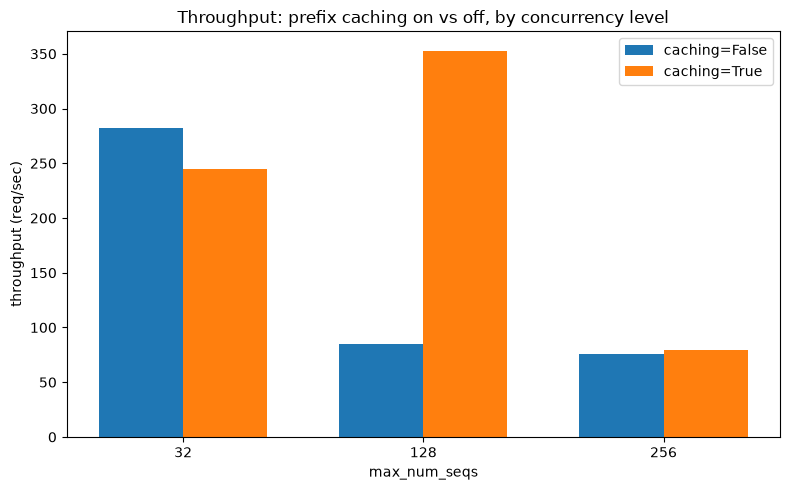

In [15]:
import matplotlib.pyplot as plt

configs = ["32", "128", "256"]
false_vals = [281.9, 85.3, 76.2]   # from your False runs, avg of sorted/shuffled
true_vals = [245.2, 352.9, 79.7]   # from your True runs, avg of sorted/shuffled

x = range(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], false_vals, width, label="caching=False")
ax.bar([i + width/2 for i in x], true_vals, width, label="caching=True")
ax.set_xticks(list(x))
ax.set_xticklabels(configs)
ax.set_xlabel("max_num_seqs")
ax.set_ylabel("throughput (req/sec)")
ax.set_title("Throughput: prefix caching on vs off, by concurrency level")
ax.legend()
plt.tight_layout()
plt.savefig("throughput_comparison.png", dpi=150)
plt.show()

In [14]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 45.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 103.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
